In [1]:
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import matplotlib.pyplot as plt
import shapiq
import src

### Load model

In [2]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.to('cuda')
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


### Load data

In [3]:
input_text = "black dog next to a yellow hydrant"
input_image = Image.open("assets/dog_and_hydrant.png")

### Build imputer with GradientGuidedSegmenter

In [4]:
from ImputerFactory import ImageImputerFactory
from Game.game_huggingface import VisionLanguageGame

factory = ImageImputerFactory()
imputer = factory.build(
    model, processor, input_image, input_text,
    segmenter="gradient_guided",
)
game = VisionLanguageGame(imputer, batch_size=64)
n_players_image = game.n_players_image
n_players_text = game.n_players_text
print(f"n_img={n_players_image}, n_txt={n_players_text}, layout={imputer.layout}")

d:\anaconda3\envs\fixlip\lib\site-packages\transformers\models\clip\modeling_clip.py:546: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


n_img=44, n_txt=8, layout=SpatialLayout(n_players_image=44, n_players_text=8, image_size=224, patch_size=32, grid_size=7, n_channels=3, model_type='clip', text_total_length=10, is_stateful=False)


### Visualize segmenter internals

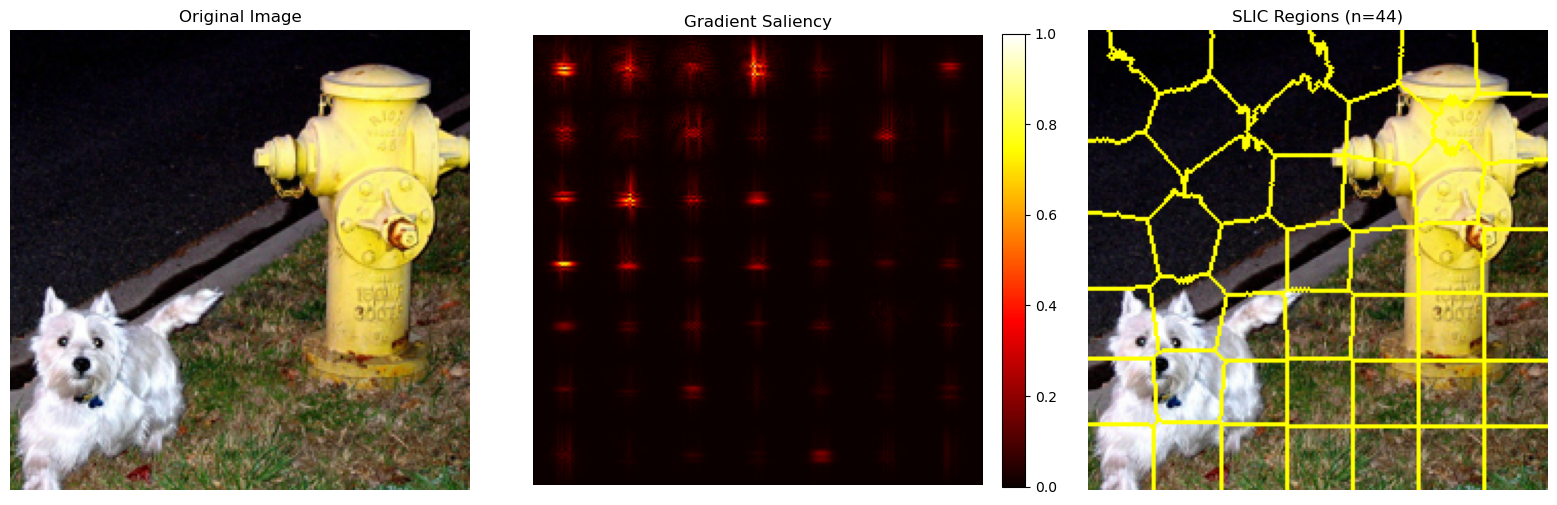

In [5]:
seg = imputer.segmenter

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Original image (denormalized)
img_denorm = src.utils.denormalize(
    game.inputs['pixel_values'].squeeze(0),
    game.processor.image_processor.image_mean,
    game.processor.image_processor.image_std,
).permute(1, 2, 0).cpu().numpy()
axes[0].imshow(img_denorm)
axes[0].set_title("Original Image")
axes[0].axis("off")

# 2. Saliency map
sal = seg._saliency
im = axes[1].imshow(sal, cmap="hot", interpolation="bilinear")
axes[1].set_title(f"Gradient Saliency")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

# 3. SLIC regions overlaid
from skimage.segmentation import mark_boundaries
label_map = seg._label_map.numpy() if hasattr(seg, '_label_map') else seg._region_map.numpy()
axes[2].imshow(mark_boundaries(img_denorm, label_map, mode="thick"))
axes[2].set_title(f"SLIC Regions (n={n_players_image})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Define approximator

In [6]:
fixlip = src.fixlip.FIxLIP(
    n_players_image=n_players_image,
    n_players_text=n_players_text,
    max_order=2,
    p=0.5,
    mode="banzhaf",
    random_state=0
)

### Compute explanation

In [7]:
src.utils.set_seed(0)
interaction_values = fixlip.approximate_crossmodal(game, budget=2**18)
print(interaction_values)

InteractionValues(
    index=FWBII, max_order=2, min_order=0, estimated=True, estimation_budget=262072,
    n_players=52, baseline_value=3.5221741908767847,
    Top 10 interactions:
        (): 3.5221741908767847
        (49,): 2.0097768336733837
        (50, 51): 1.9311780188983314
        (27, 50): 1.8749872401543608
        (44,): 1.7626020776014393
        (14, 50): 1.338212915879007
        (44, 45): -1.581486619855748
        (47,): -2.2589695214486847
        (51,): -4.268202162414494
        (50,): -7.1823811564443485
)


### Visualize explanation

<string>:12: UserWarning: Index FWBII is not a valid index as defined in {'CHGV', 'STII', 'CHII', 'k-SII', 'FBII', 'SGV', 'SII', 'IGV', 'SV', 'EGV', 'FSII', 'JointSV', 'Co-Moebius', 'BII', 'kADD-SHAP', 'ELC', 'EC', 'Moebius', 'BV', 'BGV'}. This might lead to unexpected behavior.


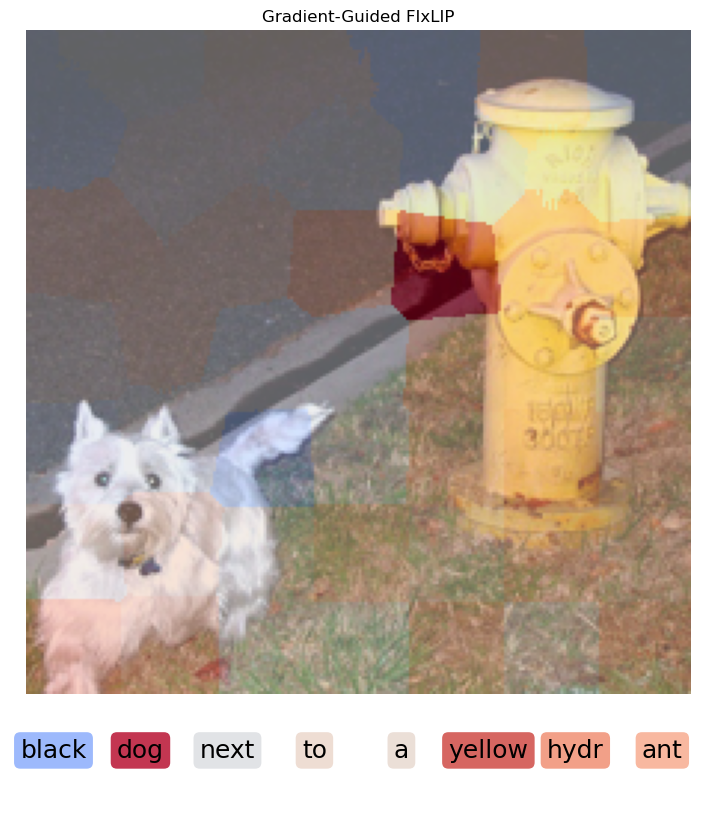

In [8]:
# Extract first-order Shapley values and split image/text
import numpy as np
first_order = src.utils.convert_iv_to_first_order(interaction_values)
values = first_order.get_n_order(1).values
image_values = values[:n_players_image]

text_tokens = game.inputs.tokens()
text_tokens = text_tokens[1:-1]
text_tokens = [token.replace('</w>', '') for token in text_tokens]
text_values = values[n_players_image:n_players_image + len(text_tokens)]

# Superpixel heatmap (works with arbitrary region count)
label_map = imputer.segmenter._label_map.cpu().numpy()
superpixel_heatmap = image_values[label_map]

max_abs_image = np.quantile(np.abs(image_values), 0.99)
if max_abs_image == 0 or not np.isfinite(max_abs_image):
    max_abs_image = np.max(np.abs(image_values)) if image_values.size else 1.0
max_abs_text = np.max(np.abs(text_values)) if text_values.size else 1.0
if max_abs_text == 0 or not np.isfinite(max_abs_text):
    max_abs_text = 1.0

input_image_processed = game.inputs['pixel_values'].squeeze(0)
input_image_denormalized = src.utils.denormalize(
    input_image_processed,
    game.processor.image_processor.image_mean,
    game.processor.image_processor.image_std
).permute(1, 2, 0).numpy()

cmap = plt.get_cmap("coolwarm")
fig, (ax_img, ax_text) = plt.subplots(
    2, 1, figsize=(7, 8),
    gridspec_kw={"height_ratios": [7, 1.15]},
)
ax_img.imshow(input_image_denormalized)
overlay = ax_img.imshow(
    superpixel_heatmap, alpha=0.45, cmap="coolwarm",
    vmin=-max_abs_image, vmax=max_abs_image,
)
ax_img.axis("off")
ax_img.set_title("Gradient-Guided FIxLIP")

ax_text.set_xlim(0, 1)
ax_text.set_ylim(0, 1)
ax_text.axis("off")
n_tokens = max(len(text_tokens), 1)
for i, token in enumerate(text_tokens):
    value = text_values[i] if i < len(text_values) else 0.0
    color = cmap((value / max_abs_text + 1.0) / 2.0)
    x = (i + 0.5) / n_tokens
    ax_text.text(
        x, 0.5, token,
        ha="center", va="center", fontsize=18,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": color,
               "edgecolor": "none", "alpha": 0.8},
    )
plt.tight_layout(pad=0.15)
plt.show()